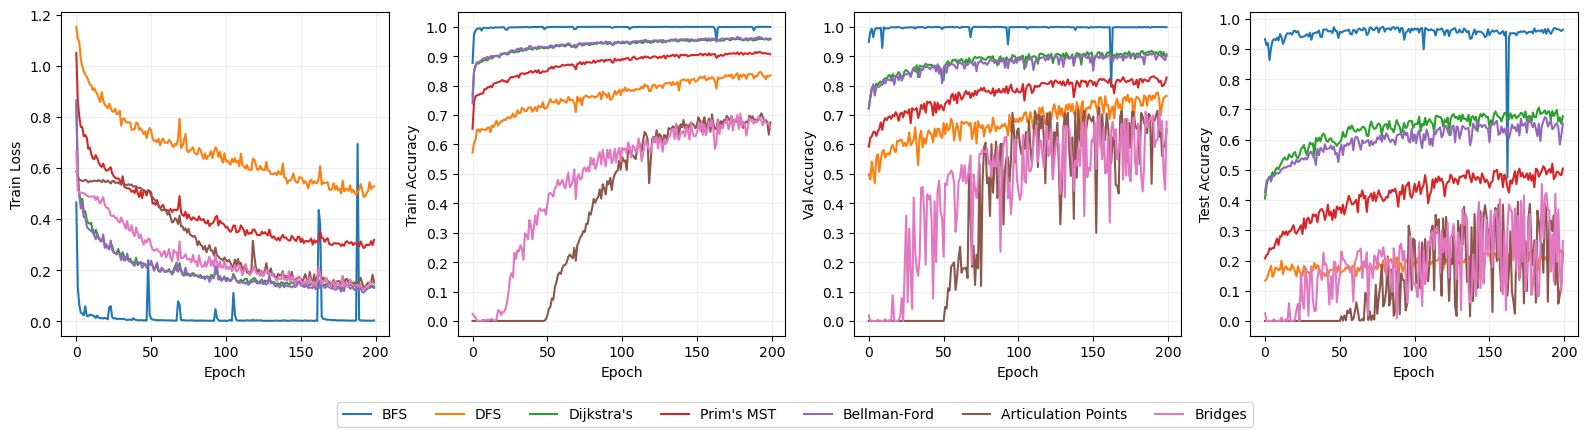

In [4]:
import matplotlib.pyplot as plt
import torch

algorithms=['bfs', 'dfs', 'dijkstra', 'mst_prim', 'bellman_ford', 'articulation_points', 'bridges']
algorithms_plotting = ['BFS', 'DFS', "Dijkstra's", 'Prim\'s MST', 'Bellman-Ford', 'Articulation Points', 'Bridges']
lr=0.001
eta=0.0001
weight_decay=0.1
schedule=False
lambda_hint = 1.0
lambda_hidden = 0.1
batch_size=32
epochs=200
seed=0
model='GINE'

fig, ax = plt.subplots(1, 4, figsize=(16,4))
config_str = f'new_all_tasks_distributed_{model}_l1_schedule_lr={lr}_eta={eta}_weight_decay={weight_decay}_lambda_hint={lambda_hint}_lambda_hidden={lambda_hidden}_schedule={schedule}_batch_size={batch_size}_seed={seed}_hidden_dim=128'
checkpoint_path = f'/qfs/projects/stargazer/share/minar/new_experiments/checkpoints/{config_str}/'
task_losses = torch.load(f'{checkpoint_path}task_losses.pt')
train_accs = torch.load(f'{checkpoint_path}train_accs.pt')
val_accs = torch.load(f'{checkpoint_path}val_accs.pt')
test_accs = torch.load(f'{checkpoint_path}test_accs.pt')
for task in algorithms:
    ax[0].plot(task_losses[task][:epochs], label=task)
    ax[1].plot(train_accs[task][:epochs], label=task)
    ax[2].plot(val_accs[task][:epochs], label=task)
    ax[3].plot(test_accs[task][:epochs], label=task)
ax[1].set_yticks(torch.arange(0,1.1,0.1))
ax[2].set_yticks(torch.arange(0,1.1,0.1))
ax[3].set_yticks(torch.arange(0,1.1,0.1))
ax[0].grid(alpha=.2)
ax[1].grid(alpha=.2)
ax[2].grid(alpha=.2)
ax[3].grid(alpha=.2)
ax[0].set_ylabel('Train Loss')
ax[1].set_ylabel('Train Accuracy')
ax[2].set_ylabel('Val Accuracy')
ax[3].set_ylabel('Test Accuracy')
ax[0].set_xlabel('Epoch')
ax[1].set_xlabel('Epoch')
ax[2].set_xlabel('Epoch')
ax[3].set_xlabel('Epoch')
fig.legend(algorithms_plotting, loc='lower center', ncol=len(algorithms_plotting), bbox_to_anchor=(0.5, -0.1))
# fig.suptitle(f'SALSA-CLRS Training Curves')
fig.tight_layout()
fig.savefig(f'salsa_clrs_training_curves_{config_str}.png', bbox_inches='tight')
fig.show()

In [2]:
print({task : val_accs[task][199] for task in algorithms})
print({task : test_accs[task][199] for task in algorithms})

{'bfs': 0.9986250400543213, 'dfs': 0.76500004529953, 'dijkstra': 0.901062548160553, 'mst_prim': 0.8272624611854553, 'bellman_ford': 0.9068709015846252, 'articulation_points': 0.6515863537788391, 'bridges': 0.6776454448699951}
{'bfs': 0.9640000462532043, 'dfs': 0.21901251375675201, 'dijkstra': 0.6775875687599182, 'mst_prim': 0.5042375326156616, 'bellman_ford': 0.6523500084877014, 'articulation_points': 0.23026685416698456, 'bridges': 0.26516422629356384}


Total L0 Norm (Number of Non-zero Parameters): 49413
Total Non-zero Weights: 48506


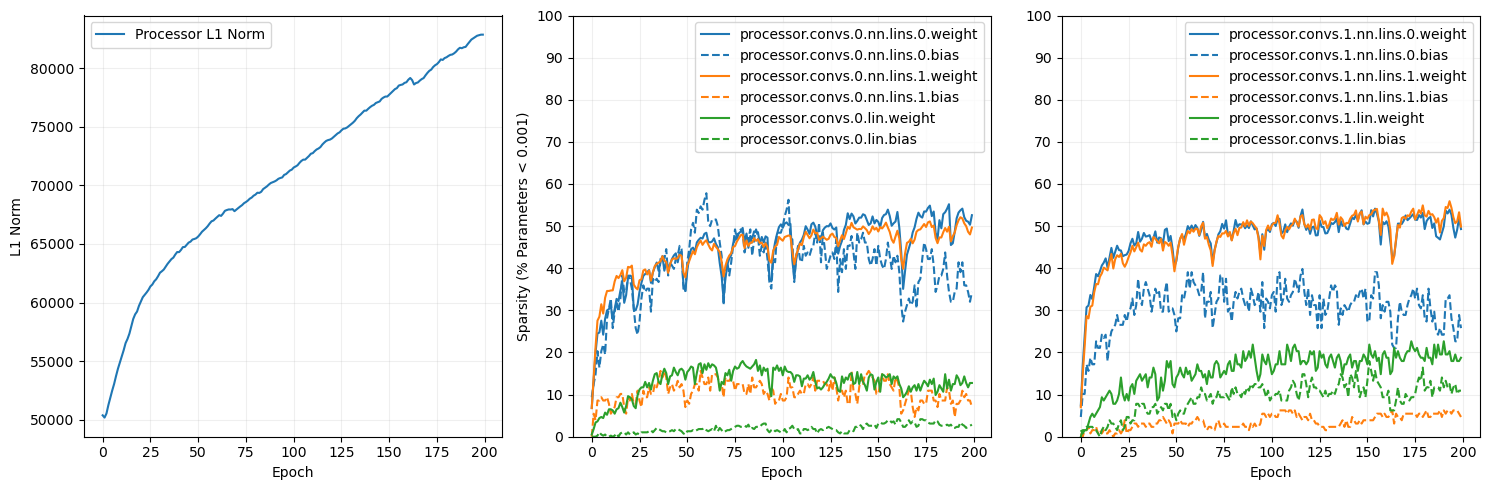

In [5]:
eps = 1e-3

fig, ax = plt.subplots(1, 3, figsize=(15,5))
l1_regs = torch.load(f'{checkpoint_path}l1_norms.pt')
ax[0].plot(l1_regs[:epochs], label='Processor L1 Norm')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('L1 Norm')
ax[0].grid(alpha=.2)
ax[0].legend()

sparsities = {}
for i in range(min(len(l1_regs), epochs)):
    checkpoint = torch.load(f'{checkpoint_path}model_in_progress_{i}.pt', map_location='cpu')
    for name, param in checkpoint.items():
        if 'processor' in name:
            num_params = param.numel()
            l0 = torch.sum(torch.abs(param) > eps).item()
            sparsities[name] = sparsities.get(name, []) + [100.0 * (1 - l0 / num_params)]
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
for name, sparsity in sparsities.items():
    if "lins.0" in name:
            color = colors[0]
    elif "lins.1" in name:
        color = colors[1]
    else:
        color = colors[2]
    if 'convs.0' in name:
        if 'weight' in name:
            ax[1].plot(sparsity[:epochs], label=name, color=color)
        elif 'bias' in name:
            ax[1].plot(sparsity[:epochs], label=name, linestyle='--', color=color)
    elif 'convs.1' in name:
        if 'weight' in name:
            ax[2].plot(sparsity[:epochs], label=name, color=color)
        elif 'bias' in name:
            ax[2].plot(sparsity[:epochs], label=name, linestyle='--', color=color)

ax[1].set_yticks(torch.arange(0,101,10))
ax[2].set_yticks(torch.arange(0,101,10))
ax[1].grid(alpha=.2)
ax[2].grid(alpha=.2)
ax[1].set_ylim(0, 100)
ax[2].set_ylim(0, 100)
ax[1].set_xlabel('Epoch')
ax[2].set_xlabel('Epoch')
ax[1].set_ylabel('Sparsity (% Parameters < 0.001)')
ax[1].legend()
ax[2].legend()
# fig.suptitle(f'lr={lr}, eta={eta}, weight_decay={weight_decay}')
fig.tight_layout()
fig.savefig(f'salsa_clrs_sparsity_{config_str}.png', bbox_inches='tight')
fig.show()

checkpoint = torch.load(f'{checkpoint_path}model_in_progress_{epochs-1}.pt', map_location='cpu')
l0_norm = 0
nonzero_weights = 0
for name, param in checkpoint.items():
    if 'processor' in name:
        num_params = param.numel()
        l0 = torch.sum(torch.abs(param) > eps).item()
        l0_norm += l0
        if 'weight' in name:
            nonzero_weights += l0
print(f'Total L0 Norm (Number of Non-zero Parameters): {l0_norm}')
print(f'Total Non-zero Weights: {nonzero_weights}')